In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [2]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.40MB/s]


In [3]:
print("Training Images:", len(train_data))
print("Testing Images:", len(test_data))

Training Images: 60000
Testing Images: 10000


In [4]:
image , label = train_data[0]
print(image.shape)
print(label)

torch.Size([1, 28, 28])
9


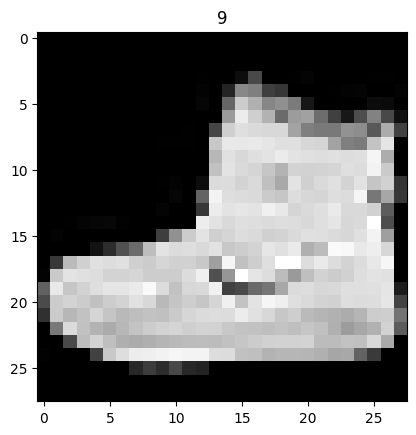

In [5]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(label)
plt.show()

In [6]:
class_names = train_data.classes # classes already built in attribute
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_data.class_to_idx # class_to_idx already built in attribute
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
train_data.targets
# images - train_data.data
# labels - train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

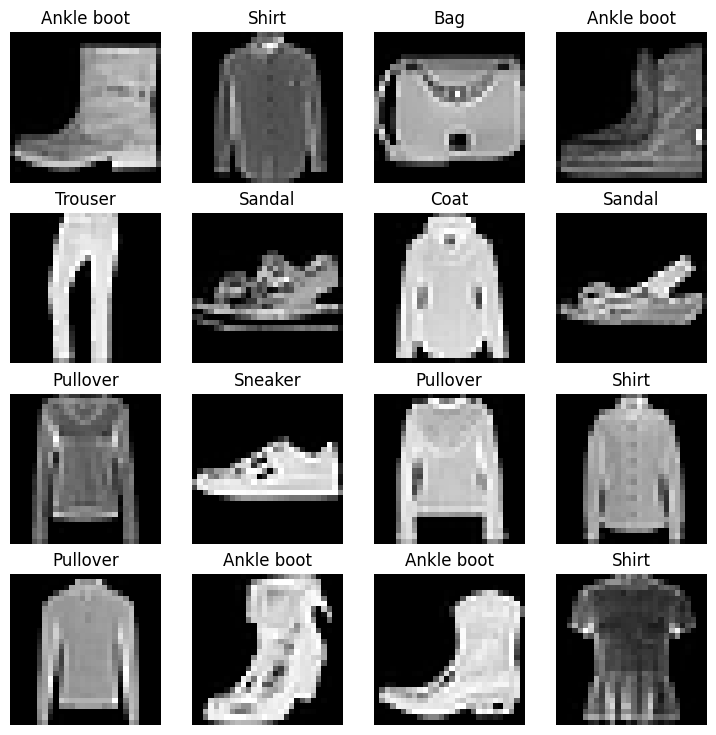

In [9]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize = (9,9))
rows , cols = 4,4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()  # size =[1] , gives how many random images we want , for this we want 1
  image , label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap = "grey")
  plt.title(class_names[label])
  plt.axis(False)


In [10]:
train_data , test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [11]:
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = 64,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                              batch_size = 64,
                              shuffle = False)



train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a0f5486ff50>,
 <torch.utils.data.dataloader.DataLoader at 0x7a0f5575e9c0>)

In [12]:
# Let's check what we have created
print(f"Dataloader: {train_dataloader,test_dataloader}\n")
print(f"Length of train dataloader: {len(train_dataloader)}\n")
print(f"Length of test dataloader: {len(test_dataloader)}\n")


Dataloader: (<torch.utils.data.dataloader.DataLoader object at 0x7a0f5486ff50>, <torch.utils.data.dataloader.DataLoader object at 0x7a0f5575e9c0>)

Length of train dataloader: 938

Length of test dataloader: 157



In [13]:
#check out what's inside the training dataloader
image, labels = next(iter(train_dataloader))
print(image.shape)
print(labels.shape)
# Create an iterator from the DataLoader
# ↓
# Take the first batch
# ↓
# Store all batch images in "images"
# ↓
# Store all batch labels in "labels"

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [14]:
import torch
import torch.nn as nn

class FashionMNISTModel(nn.Module):
    def __init__(self):
        super().__init__()

        #Flatten layer
        self.flatten = nn.Flatten()

        #hidden_layer1
        self.hidden_layer1 = nn.Linear(in_features = 784, out_features = 16)

        #Left branch
        self.left_1 = nn.Linear(16, 8)
        self.left_2 = nn.Linear(8, 8)

        # Right Branch
        self.right_1 = nn.Linear(16, 12)
        self.right_2 = nn.Linear(12, 8)

        # Output Layer
        self.output_layer = nn.Linear(16, 10)

        # ReLU introduces non-linearity into the network. Without activation functions, multiple linear layers would behave like a single linear transformation. ReLU helps the model learn complex patterns while being computationally efficient.
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.hidden_layer1(x))

        # ==================
        # Left Branch
        # ==================

        left_layer1_output = self.relu(self.left_1(x))

        left_layer2_output = self.relu(self.left_2(left_layer1_output))

        left_output = left_layer1_output + left_layer2_output

        # ==================
        # Right Branch
        # ==================

        right_layer1 = self.relu(self.right_1(x))
        right_layer2 = self.relu(self.right_2(right_layer1))

        # ==================
        # Concatenate
        # ==================

        combined = torch.cat((left_output , right_layer2), dim=1)
        #example
        #left_output   = [1,2,3,4,5,6,7,8] (batch_size , 8)
        #right_layer2 = [9,10,11,12,13,14,15,16] (batch_size , 8)
        # combined =[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16] (batch_size, 16)
        # print(left_output.shape)
        # print(right_layer2.shape)
        # print(combined.shape)

        # ==================
        # Output Layer
        # ==================

        output = self.output_layer(combined)

        return output





In [15]:
model_0 = FashionMNISTModel()

In [16]:
model_0

FashionMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer1): Linear(in_features=784, out_features=16, bias=True)
  (left_1): Linear(in_features=16, out_features=8, bias=True)
  (left_2): Linear(in_features=8, out_features=8, bias=True)
  (right_1): Linear(in_features=16, out_features=12, bias=True)
  (right_2): Linear(in_features=12, out_features=8, bias=True)
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
  (relu): ReLU()
)

In [17]:
outputs = model_0(image) # WE are checking on sending image inside our model forward function , what is the output on travelling throgh the model
#outputs = model.forward(image)
print(outputs.shape)

torch.Size([64, 10])


In [19]:
x = image

print("Original:", x.shape)

x = model_0.flatten(x)
print("Flatten:", x.shape)

x = model_0.hidden_layer1(x)
print("Hidden_leyer1 Layer:", x.shape)

Original: torch.Size([64, 1, 28, 28])
Flatten: torch.Size([64, 784])
Hidden_leyer1 Layer: torch.Size([64, 16])


In [20]:
outputs = model_0(image)
print(outputs[0]) #The predictions for the FIRST IMAGE in the batch

tensor([-0.1084, -0.0254, -0.1878, -0.2266, -0.0931,  0.0289, -0.0800,  0.1865,
        -0.0996, -0.3144], grad_fn=<SelectBackward0>)


In [21]:
torch.argmax(outputs[0])

tensor(7)

In [22]:
pred_class = torch.argmax(outputs[0])

print(pred_class)
print(class_names[pred_class])

tensor(7)
Sneaker


In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam( #Adam was chosen because it adapts learning rates automatically for different parameters, generally converges faster than vanilla SGD, and works well for image-classification tasks like FashionMNIST with minimal hyperparameter tuning.
    model_0.parameters(),
    lr=0.001
)

In [40]:
epochs = 5
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(epochs):

    # ==========================
    # TRAINING
    # ==========================

    model_0.train()

    train_loss = 0
    train_correct = 0

    for images, labels in train_dataloader:

        # Forward Pass
        outputs = model_0(images)

        # Loss
        loss = loss_fn(outputs, labels)

        # Reset Gradients
        optimizer.zero_grad()

        # Backward Pass
        loss.backward()

        # Update Weights
        optimizer.step()

        # Accumulate Loss
        train_loss += loss.item() # .item is used to extract the no. out of the tensor , loss is a tensor

        # Predictions
        preds = torch.argmax(outputs, dim=1)

        # Count Correct Predictions
        train_correct += (preds == labels).sum().item()

    # Average Training Loss
    train_loss /= len(train_dataloader)

    # Training Accuracy
    train_accuracy = (
        train_correct / len(train_dataloader.dataset)
    ) * 100

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # ==========================
    # VALIDATION / TEST
    # ==========================

    model_0.eval()

    val_loss = 0
    val_correct = 0

    with torch.inference_mode():

        for images, labels in test_dataloader:

            outputs = model_0(images)

            loss = loss_fn(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == labels).sum().item()

    # Average Validation Loss
    val_loss /= len(test_dataloader)

    # Validation Accuracy
    val_accuracy = (
        val_correct / len(test_dataloader.dataset)
    ) * 100

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # ==========================
    # PRINT RESULTS
    # ==========================

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")


Epoch 1/5
Train Loss: 0.3275
Train Accuracy: 88.23%
Validation Loss: 0.3809
Validation Accuracy: 86.45%

Epoch 2/5
Train Loss: 0.3219
Train Accuracy: 88.39%
Validation Loss: 0.3862
Validation Accuracy: 86.10%

Epoch 3/5
Train Loss: 0.3192
Train Accuracy: 88.50%
Validation Loss: 0.3959
Validation Accuracy: 86.18%

Epoch 4/5
Train Loss: 0.3158
Train Accuracy: 88.52%
Validation Loss: 0.3886
Validation Accuracy: 86.14%

Epoch 5/5
Train Loss: 0.3139
Train Accuracy: 88.74%
Validation Loss: 0.3874
Validation Accuracy: 86.67%


In [26]:
import torch

torch.save(model_0.state_dict(), "fashion_mnist_model.pth")

In [41]:
model_0.state_dict()


OrderedDict([('hidden_layer1.weight',
              tensor([[-0.0165, -0.0042, -0.0145,  ...,  0.0142, -0.0319,  0.0206],
                      [ 0.5925, -0.3470,  0.0018,  ..., -0.3272,  0.3559,  0.3820],
                      [-0.4107, -0.5214, -0.5704,  ...,  0.3669,  0.7220, -0.5843],
                      ...,
                      [ 0.0286, -0.0195, -0.0021,  ...,  0.0217,  0.0060,  0.0060],
                      [ 0.5262,  0.1654, -0.2209,  ..., -0.2301, -0.2040,  0.1573],
                      [-0.1616, -0.1243, -0.0326,  ...,  0.1657, -0.6361,  0.1377]])),
             ('hidden_layer1.bias',
              tensor([-0.0352, -0.0750, -0.2921, -0.2793,  0.5695,  0.1299, -0.0441, -0.2515,
                       0.3799, -0.0510,  0.3403,  0.1719,  0.5132,  0.0133,  0.7538,  0.5858])),
             ('left_1.weight',
              tensor([[ 0.0283,  0.0233,  0.0145,  0.5754,  0.1906,  0.3319,  0.4062, -0.2574,
                       -0.2908,  0.2271,  0.1560, -0.1743,  0.1580, -0.2197

In [27]:
import random

random_idx = random.randint(0, len(test_data)-1)

image, label = test_data[random_idx]

model_0.eval()

with torch.inference_mode():

    prediction = model_0(image.unsqueeze(0))

pred_label = torch.argmax(prediction, dim=1)

print("Actual:", class_names[label])
print("Predicted:", class_names[pred_label])

Actual: Pullover
Predicted: Pullover


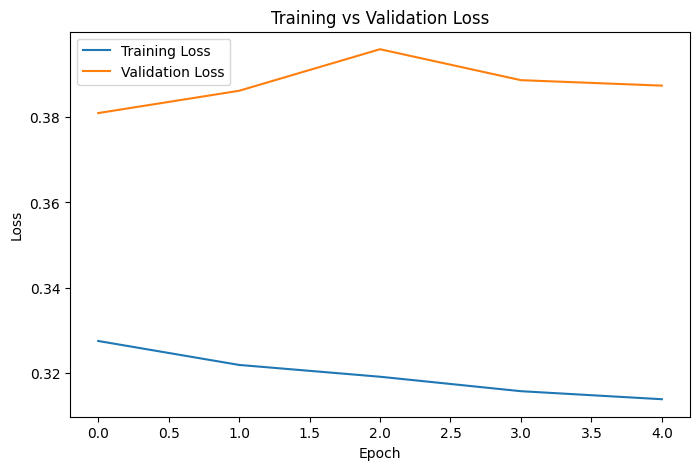

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

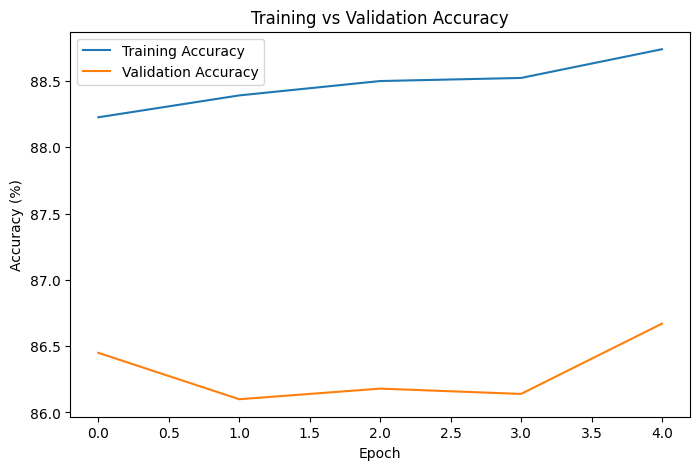

In [46]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [47]:
import pickle

with open("fashion_mnist_model.pkl", "wb") as f:
    pickle.dump(model_0.state_dict(), f)


In [48]:
import os

print(os.listdir())


['.config', 'fashion_mnist_model.pth', 'submission.csv', 'fashion_mnist_model.pkl', 'data', 'sample_data']


In [33]:
import pandas as pd

predictions = []

model_0.eval()

with torch.inference_mode():

    for images, labels in test_dataloader:

        outputs = model_0(images)

        preds = torch.argmax(outputs, dim=1) #argmax does NOT return the largest value.
                                             #It returns the index (position) of the largest value.

        predictions.extend(preds.numpy())

In [49]:
submission = pd.DataFrame({
    "Prediction": predictions
})

submission.head() #and head() only shows the first 5 rows by default.


,Prediction
0,9
1,2
2,1
3,1
4,6


In [50]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [51]:
print(submission.shape)


(10000, 1)


In [53]:
from google.colab import files

files.download("fashion_mnist_model.pkl")
files.download("submission.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import pickle

with open("fashion_mnist_model.pkl", "rb") as f:
    loaded_weights = pickle.load(f)

print(type(loaded_weights))

<class 'collections.OrderedDict'>


In [42]:
model_0 = FashionMNISTModel()

In [43]:
model_0.load_state_dict(
    torch.load("fashion_mnist_model.pth")
)

<All keys matched successfully>

In [44]:
model_0

FashionMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer1): Linear(in_features=784, out_features=16, bias=True)
  (left_1): Linear(in_features=16, out_features=8, bias=True)
  (left_2): Linear(in_features=8, out_features=8, bias=True)
  (right_1): Linear(in_features=16, out_features=12, bias=True)
  (right_2): Linear(in_features=12, out_features=8, bias=True)
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
  (relu): ReLU()
)